In [1]:
# Cell 1: Imports and paths

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

REPO_ROOT = Path("..").resolve()  # if notebook is in notebooks/
PREDICTION_PATH = REPO_ROOT / "outputs/predictions/baseline_predictions_with_boosting.parquet"

OUTPUT_DIR = REPO_ROOT / "outputs/backtests"
FIGURE_DIR = OUTPUT_DIR / "figures"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

PREDICTION_PATH

PosixPath('/home/aturin/ML/ML_For_Finance_Project-AxelTurinPlessia-362559-ClementMeddeb-346164/outputs/predictions/baseline_predictions_with_boosting.parquet')

In [2]:
# Cell 2: Load predictions

df = pd.read_parquet(PREDICTION_PATH)

df["MthCalDt"] = pd.to_datetime(df["MthCalDt"])
df["split"] = df["split"].astype(str)

required_columns = [
    "PERMNO",
    "MthCalDt",
    "split",
    "target_ret_1m",
    "top_bottom_label",
]

missing = [c for c in required_columns if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df = df.sort_values(["MthCalDt", "PERMNO"]).reset_index(drop=True)

print(df.shape)
df.head()

(3112347, 20)


,PERMNO,gvkey,MthCalDt,split,target_ret_1m,target_quintile,top_bottom_label,prediction_naive_momentum,prediction_naive_reversal,prediction_ridge,prediction_elastic_net,prediction_gradient_boosting_reg,prediction_logistic_classifier_score,prediction_gb_classifier_score,prob_logistic_bottom,prob_logistic_middle,prob_logistic_top,prob_gb_bottom,prob_gb_middle,prob_gb_top
0,10001,012994,1990-01-31,train,-0.006289,3,1,0.626005,-0.037975,0.022786,0.01728,0.017175,-0.003940,0.037282,0.053190,0.897560,0.049250,0.128834,0.705050,0.166116
1,10002,019049,1990-01-31,train,0.020000,3,1,-0.238806,0.039216,0.021678,0.01728,0.013274,-0.012533,0.022095,0.053145,0.906243,0.040612,0.077321,0.823262,0.099417
2,10003,016950,1990-01-31,train,0.258065,5,2,-0.366290,0.260870,0.028677,0.01728,0.014572,-0.052498,-0.037200,0.134532,0.783434,0.082034,0.303214,0.430771,0.266014
3,10005,012087,1990-01-31,train,-0.250000,1,0,-0.333334,-0.000000,0.022573,0.01728,0.015767,-0.022883,-0.059777,0.088554,0.845775,0.065671,0.297353,0.465071,0.237576
4,10007,009636,1990-01-31,train,-0.147826,1,0,0.043868,-0.450331,-0.001760,0.01728,0.011867,0.004314,-0.041851,0.095935,0.803817,0.100249,0.345136,0.351580,0.303285


In [3]:
# Cell 3: Basic validation

def validate_prediction_frame(data: pd.DataFrame) -> None:
    key_dupes = data.duplicated(["PERMNO", "MthCalDt"]).sum()
    if key_dupes:
        raise ValueError(f"Duplicate PERMNO-MthCalDt rows found: {key_dupes:,}")

    if data["target_ret_1m"].isna().any():
        raise ValueError("target_ret_1m contains missing values.")

    print("Prediction frame validation passed.")
    print("Rows:", f"{len(data):,}")
    print("Date range:", data["MthCalDt"].min(), "to", data["MthCalDt"].max())
    print(data["split"].value_counts().sort_index())

validate_prediction_frame(df)

Prediction frame validation passed.
Rows: 3,112,347
Date range: 1990-01-31 00:00:00 to 2024-11-29 00:00:00
split
test           878515
train         1828568
validation     405264
Name: count, dtype: int64


In [4]:
# Cell 4: Score construction helpers

def cross_sectional_zscore(data: pd.DataFrame, value_col: str, date_col: str = "MthCalDt") -> pd.Series:
    values = pd.to_numeric(data[value_col], errors="coerce")
    mean = values.groupby(data[date_col]).transform("mean")
    std = values.groupby(data[date_col]).transform("std")
    z = (values - mean) / std.replace(0, np.nan)
    return z.fillna(0.0)


def add_training_class_mean_score(
    data: pd.DataFrame,
    prob_cols: dict,
    label_col: str = "top_bottom_label",
    target_col: str = "target_ret_1m",
    split_col: str = "split",
    output_col: str = "score_er_train",
) -> pd.DataFrame:
    out = data.copy()

    train = out[split_col].eq("train")
    class_means = (
        out.loc[train]
        .groupby(label_col)[target_col]
        .mean()
        .reindex([0, 1, 2])
    )

    if class_means.isna().any():
        raise ValueError(f"Missing class means: {class_means}")

    out[output_col] = (
        out[prob_cols[0]] * class_means.loc[0]
        + out[prob_cols[1]] * class_means.loc[1]
        + out[prob_cols[2]] * class_means.loc[2]
    )

    return out


def add_predicted_return_bucket_score(
    data: pd.DataFrame,
    prob_cols: dict,
    pred_return_col: str,
    date_col: str = "MthCalDt",
    output_col: str = "score_er_pred_return_buckets",
) -> pd.DataFrame:
    """
    Bucket stocks each month using predicted return ranking:
    bottom 20%, middle 60%, top 20%.
    Then value classifier probabilities using average predicted return in each bucket.
    """
    out = data.copy()
    pred = pd.to_numeric(out[pred_return_col], errors="coerce")

    ranks = pred.groupby(out[date_col]).rank(method="first", pct=True)

    bucket = pd.Series(np.nan, index=out.index)
    bucket[ranks <= 0.20] = 0
    bucket[(ranks > 0.20) & (ranks < 0.80)] = 1
    bucket[ranks >= 0.80] = 2
    out["_pred_return_bucket"] = bucket.astype("Int64")

    bucket_means = (
        out.groupby([date_col, "_pred_return_bucket"], observed=True)[pred_return_col]
        .mean()
        .unstack("_pred_return_bucket")
        .rename(columns={0: "_mu0", 1: "_mu1", 2: "_mu2"})
    )

    out = out.merge(bucket_means, on=date_col, how="left")

    out[output_col] = (
        out[prob_cols[0]] * out["_mu0"]
        + out[prob_cols[1]] * out["_mu1"]
        + out[prob_cols[2]] * out["_mu2"]
    )

    out = out.drop(columns=["_pred_return_bucket", "_mu0", "_mu1", "_mu2"])
    return out


def add_classifier_bucket_predicted_return_score(
    data: pd.DataFrame,
    prob_cols: dict,
    classifier_score_col: str,
    pred_return_col: str,
    date_col: str = "MthCalDt",
    output_col: str = "score_er_pred_classifier_buckets",
) -> pd.DataFrame:
    """
    Bucket stocks each month using classifier-score ranking:
    bottom 20%, middle 60%, top 20%.
    Then value these classifier buckets by average predicted return.
    """
    out = data.copy()

    score = pd.to_numeric(out[classifier_score_col], errors="coerce")
    ranks = score.groupby(out[date_col]).rank(method="first", pct=True)

    bucket = pd.Series(np.nan, index=out.index)
    bucket[ranks <= 0.20] = 0
    bucket[(ranks > 0.20) & (ranks < 0.80)] = 1
    bucket[ranks >= 0.80] = 2
    out["_classifier_bucket"] = bucket.astype("Int64")

    bucket_means = (
        out.groupby([date_col, "_classifier_bucket"], observed=True)[pred_return_col]
        .mean()
        .unstack("_classifier_bucket")
        .rename(columns={0: "_mu0", 1: "_mu1", 2: "_mu2"})
    )

    out = out.merge(bucket_means, on=date_col, how="left")

    out[output_col] = (
        out[prob_cols[0]] * out["_mu0"]
        + out[prob_cols[1]] * out["_mu1"]
        + out[prob_cols[2]] * out["_mu2"]
    )

    out = out.drop(columns=["_classifier_bucket", "_mu0", "_mu1", "_mu2"])
    return out

In [5]:
# Cell 5: Build candidate scores

work = df.copy()

# Default scores already produced by the baseline script.
score_columns = {
    "naive_momentum": "prediction_naive_momentum",
    "naive_reversal": "prediction_naive_reversal",
    "ridge": "prediction_ridge",
    "elastic_net": "prediction_elastic_net",
    "xgb_regressor": "prediction_gradient_boosting_reg",
    "logistic_classifier": "prediction_logistic_classifier_score",
    "xgb_classifier": "prediction_gb_classifier_score",
}

# Probability column maps.
logistic_probs = {
    0: "prob_logistic_bottom",
    1: "prob_logistic_middle",
    2: "prob_logistic_top",
}

xgb_probs = {
    0: "prob_gb_bottom",
    1: "prob_gb_middle",
    2: "prob_gb_top",
}

# Training-set realized class-mean expected-return scores.
work = add_training_class_mean_score(
    work,
    prob_cols=logistic_probs,
    output_col="score_logistic_er_train",
)
score_columns["logistic_er_train"] = "score_logistic_er_train"

work = add_training_class_mean_score(
    work,
    prob_cols=xgb_probs,
    output_col="score_xgb_er_train",
)
score_columns["xgb_er_train"] = "score_xgb_er_train"

# Hybrid score: classifier score + standardized XGBoost regressor forecast.
work["z_xgb_regressor"] = cross_sectional_zscore(work, "prediction_gradient_boosting_reg")

for alpha in [0.25, 0.50, 0.75, 0.90]:
    col = f"score_xgb_hybrid_alpha_{str(alpha).replace('.', '_')}"
    work[col] = (
        alpha * work["prediction_gb_classifier_score"]
        + (1 - alpha) * work["z_xgb_regressor"]
    )
    score_columns[f"xgb_hybrid_alpha_{alpha:.2f}"] = col

# Predicted-return bucket expected-return scores.
work = add_predicted_return_bucket_score(
    work,
    prob_cols=xgb_probs,
    pred_return_col="prediction_gradient_boosting_reg",
    output_col="score_xgb_er_pred_return_buckets",
)
score_columns["xgb_er_pred_return_buckets"] = "score_xgb_er_pred_return_buckets"

work = add_classifier_bucket_predicted_return_score(
    work,
    prob_cols=xgb_probs,
    classifier_score_col="prediction_gb_classifier_score",
    pred_return_col="prediction_gradient_boosting_reg",
    output_col="score_xgb_er_pred_classifier_buckets",
)
score_columns["xgb_er_pred_classifier_buckets"] = "score_xgb_er_pred_classifier_buckets"

score_columns

{'naive_momentum': 'prediction_naive_momentum',
 'naive_reversal': 'prediction_naive_reversal',
 'ridge': 'prediction_ridge',
 'elastic_net': 'prediction_elastic_net',
 'xgb_regressor': 'prediction_gradient_boosting_reg',
 'logistic_classifier': 'prediction_logistic_classifier_score',
 'xgb_classifier': 'prediction_gb_classifier_score',
 'logistic_er_train': 'score_logistic_er_train',
 'xgb_er_train': 'score_xgb_er_train',
 'xgb_hybrid_alpha_0.25': 'score_xgb_hybrid_alpha_0_25',
 'xgb_hybrid_alpha_0.50': 'score_xgb_hybrid_alpha_0_5',
 'xgb_hybrid_alpha_0.75': 'score_xgb_hybrid_alpha_0_75',
 'xgb_hybrid_alpha_0.90': 'score_xgb_hybrid_alpha_0_9',
 'xgb_er_pred_return_buckets': 'score_xgb_er_pred_return_buckets',
 'xgb_er_pred_classifier_buckets': 'score_xgb_er_pred_classifier_buckets'}

In [6]:
# Cell 6: Monthly Rank IC

def monthly_rank_ic(
    data: pd.DataFrame,
    score_col: str,
    target_col: str = "target_ret_1m",
    date_col: str = "MthCalDt",
    split_col: str = "split",
) -> pd.DataFrame:
    rows = []

    for (split, month), part in data.groupby([split_col, date_col], sort=True):
        scores = pd.to_numeric(part[score_col], errors="coerce")
        target = pd.to_numeric(part[target_col], errors="coerce")
        valid = scores.notna() & target.notna()

        if valid.sum() < 5 or scores[valid].nunique() <= 1 or target[valid].nunique() <= 1:
            ic = np.nan
        else:
            ic = scores[valid].corr(target[valid], method="spearman")

        rows.append(
            {
                "split": split,
                "month": month,
                "score_name": score_col,
                "rank_ic": ic,
                "n_stocks": int(valid.sum()),
            }
        )

    return pd.DataFrame(rows)


def summarize_rank_ic(monthly_ic: pd.DataFrame) -> pd.DataFrame:
    summary = (
        monthly_ic.dropna(subset=["rank_ic"])
        .groupby(["score_label", "split"], observed=True)["rank_ic"]
        .agg(mean_rank_ic="mean", std_rank_ic="std", months="count")
        .reset_index()
    )

    summary["rank_ic_tstat"] = (
        summary["mean_rank_ic"] / summary["std_rank_ic"] * np.sqrt(summary["months"])
    )

    return summary.sort_values(["split", "mean_rank_ic"], ascending=[True, False])


monthly_ic_frames = []

for label, col in score_columns.items():
    if col not in work.columns:
        print(f"Skipping missing score: {label} -> {col}")
        continue

    tmp = monthly_rank_ic(work, col)
    tmp["score_label"] = label
    monthly_ic_frames.append(tmp)

monthly_ic_all = pd.concat(monthly_ic_frames, ignore_index=True)
rank_ic_summary = summarize_rank_ic(monthly_ic_all)

monthly_ic_all.to_csv(OUTPUT_DIR / "score_monthly_rank_ic.csv", index=False)
rank_ic_summary.to_csv(OUTPUT_DIR / "score_rank_ic_summary.csv", index=False)

rank_ic_summary

,score_label,split,mean_rank_ic,std_rank_ic,months,rank_ic_tstat
18,xgb_classifier,test,0.077889,0.128972,108,6.276144
3,logistic_classifier,test,0.073291,0.107174,108,7.106850
6,logistic_er_train,test,0.057335,0.106312,108,5.604672
27,xgb_er_train,test,0.048846,0.091302,108,5.559828
9,naive_momentum,test,0.046997,0.129078,108,3.783776
39,xgb_hybrid_alpha_0.90,test,0.032544,0.107015,108,3.160367
36,xgb_hybrid_alpha_0.75,test,0.017691,0.106272,108,1.729974
24,xgb_er_pred_return_buckets,test,0.015889,0.171357,108,0.963618
33,xgb_hybrid_alpha_0.50,test,0.011417,0.106818,108,1.110782
30,xgb_hybrid_alpha_0.25,test,0.009310,0.107189,108,0.902662


In [7]:
# Cell 7: Show validation ranking only

validation_rank_ic = (
    rank_ic_summary.loc[rank_ic_summary["split"].eq("validation")]
    .sort_values("mean_rank_ic", ascending=False)
    .reset_index(drop=True)
)

validation_rank_ic

,score_label,split,mean_rank_ic,std_rank_ic,months,rank_ic_tstat
0,xgb_classifier,validation,0.074777,0.096928,60,5.975759
1,naive_momentum,validation,0.071057,0.132657,60,4.149069
2,logistic_classifier,validation,0.070389,0.080732,60,6.753590
3,xgb_er_train,validation,0.053715,0.100241,60,4.150729
4,logistic_er_train,validation,0.048599,0.087872,60,4.284029
5,xgb_hybrid_alpha_0.90,validation,0.041237,0.098988,60,3.226846
6,xgb_er_pred_return_buckets,validation,0.039003,0.164611,60,1.835343
7,xgb_hybrid_alpha_0.75,validation,0.028608,0.101411,60,2.185164
8,xgb_hybrid_alpha_0.50,validation,0.022796,0.101116,60,1.746270
9,xgb_hybrid_alpha_0.25,validation,0.020618,0.100611,60,1.587382


In [8]:
# Cell 8: Portfolio construction

def make_weights_for_month(
    part: pd.DataFrame,
    score_col: str,
    rule: str,
    q: float = 0.20,
    short_exposure: float = 1.0,
    long_exposure: float = 1.0,
    sign_gate: bool = False,
    threshold_gate: bool = False,
    zero_threshold: float = 0.0,
    cash_if_empty: bool = True,
) -> pd.Series:
    """
    Returns weights indexed like part.

    Rules:
    - long_only: long top q with gross/net exposure 1.
    - long_short: long top q, short bottom q with specified exposures.
    - long_short_130_30: long exposure 1.3, short exposure 0.3.
    - gross_normalized_long_short: long exposure 0.5, short exposure 0.5.

    Gates:
    - sign_gate: require positive long scores and negative short scores.
    - threshold_gate: require scores to be at least zero_threshold away from zero.
    """
    if sign_gate and threshold_gate:
        raise ValueError("Use either sign_gate or threshold_gate, not both.")

    scores = pd.to_numeric(part[score_col], errors="coerce")
    valid = scores.notna()

    weights = pd.Series(0.0, index=part.index)

    if valid.sum() < 10:
        return weights

    ranks = scores[valid].rank(method="first", pct=True)

    long_idx = ranks[ranks >= 1 - q].index
    short_idx = ranks[ranks <= q].index

    if sign_gate:
        long_idx = long_idx[scores.loc[long_idx] > 0]
        short_idx = short_idx[scores.loc[short_idx] < 0]
    elif threshold_gate:
        long_idx = long_idx[scores.loc[long_idx] > zero_threshold]
        short_idx = short_idx[scores.loc[short_idx] < -zero_threshold]

    if rule == "long_only":
        if len(long_idx) > 0:
            weights.loc[long_idx] = 1.0 / len(long_idx)
        return weights

    if rule == "long_short":
        le = long_exposure
        se = short_exposure
    elif rule == "gross_normalized_long_short":
        le = 0.5
        se = 0.5
    elif rule == "long_short_130_30":
        le = 1.3
        se = 0.3
    else:
        raise ValueError(f"Unknown rule: {rule}")

    if len(long_idx) > 0:
        weights.loc[long_idx] = le / len(long_idx)

    if len(short_idx) > 0:
        weights.loc[short_idx] = -se / len(short_idx)

    return weights


def build_portfolio_returns(
    data: pd.DataFrame,
    score_label: str,
    score_col: str,
    rule: str,
    q: float = 0.20,
    sign_gate: bool = False,
    threshold_gate: bool = False,
    zero_threshold: float = 0.0,
    one_way_cost_bps: float = 0.0,
    target_col: str = "target_ret_1m",
    date_col: str = "MthCalDt",
    split_col: str = "split",
) -> pd.DataFrame:
    """
    Builds monthly portfolio returns.

    Turnover approximation:
    sum_i |w_t - w_{t-1}| using end-of-month target weights.
    This ignores drift between rebalances, but is fine for first-pass comparison.
    """
    rows = []
    previous_weights = None

    data = data.sort_values([date_col, "PERMNO"]).copy()

    for (split, month), part in data.groupby([split_col, date_col], sort=True):
        weights = make_weights_for_month(
            part,
            score_col=score_col,
            rule=rule,
            q=q,
            sign_gate=sign_gate,
            threshold_gate=threshold_gate,
            zero_threshold=zero_threshold,
        )

        returns = pd.to_numeric(part[target_col], errors="coerce").fillna(0.0)

        gross_return = float((weights * returns).sum())

        long_weight = weights.clip(lower=0).sum()
        short_weight = -weights.clip(upper=0).sum()
        gross_exposure = weights.abs().sum()
        net_exposure = weights.sum()

        long_return = np.nan
        short_leg_return = np.nan

        if long_weight > 0:
            long_return = float((weights.clip(lower=0) * returns).sum() / long_weight)

        if short_weight > 0:
            short_leg_return = float((weights.clip(upper=0) * returns).sum())

        current_weights = pd.Series(weights.values, index=part["PERMNO"].values)

        if previous_weights is None:
            turnover = float(current_weights.abs().sum())
        else:
            aligned = pd.concat(
                [
                    previous_weights.rename("prev"),
                    current_weights.rename("curr"),
                ],
                axis=1,
            ).fillna(0.0)
            turnover = float((aligned["curr"] - aligned["prev"]).abs().sum())

        cost = (one_way_cost_bps / 10_000.0) * turnover
        net_return = gross_return - cost

        rows.append(
            {
                "split": split,
                "month": month,
                "score_label": score_label,
                "score_col": score_col,
                "rule": rule,
                "q": q,
                "sign_gate": sign_gate,
                "threshold_gate": threshold_gate,
                "zero_threshold": zero_threshold,
                "one_way_cost_bps": one_way_cost_bps,
                "gross_return": gross_return,
                "turnover": turnover,
                "trading_cost": cost,
                "net_return": net_return,
                "long_weight": float(long_weight),
                "short_weight": float(short_weight),
                "gross_exposure": float(gross_exposure),
                "net_exposure": float(net_exposure),
                "long_leg_return": long_return,
                "short_leg_contribution": short_leg_return,
                "n_long": int((weights > 0).sum()),
                "n_short": int((weights < 0).sum()),
            }
        )

        previous_weights = current_weights

    return pd.DataFrame(rows)


In [9]:
# Cell 9: Portfolio performance summary

def max_drawdown(returns: pd.Series) -> float:
    wealth = (1.0 + returns.fillna(0.0)).cumprod()
    peak = wealth.cummax()
    drawdown = wealth / peak - 1.0
    return float(drawdown.min())


def annualized_return(monthly_returns: pd.Series) -> float:
    monthly_returns = monthly_returns.dropna()
    if len(monthly_returns) == 0:
        return np.nan
    total = (1.0 + monthly_returns).prod()
    years = len(monthly_returns) / 12.0
    return float(total ** (1.0 / years) - 1.0)


def annualized_volatility(monthly_returns: pd.Series) -> float:
    monthly_returns = monthly_returns.dropna()
    if len(monthly_returns) <= 1:
        return np.nan
    return float(monthly_returns.std() * np.sqrt(12))


def sharpe_ratio(monthly_returns: pd.Series) -> float:
    ann_ret = annualized_return(monthly_returns)
    ann_vol = annualized_volatility(monthly_returns)
    if ann_vol == 0 or pd.isna(ann_vol):
        return np.nan
    return float(ann_ret / ann_vol)


def summarize_portfolios(monthly: pd.DataFrame, return_col: str = "net_return") -> pd.DataFrame:
    rows = []

    group_cols = [
        "score_label",
        "rule",
        "q",
        "sign_gate",
        "threshold_gate",
        "zero_threshold",
        "one_way_cost_bps",
        "split",
    ]

    for keys, part in monthly.groupby(group_cols, observed=True):
        score_label, rule, q, sign_gate, threshold_gate, zero_threshold, cost_bps, split = keys
        rets = part[return_col]

        rows.append(
            {
                "score_label": score_label,
                "rule": rule,
                "q": q,
                "sign_gate": sign_gate,
                "threshold_gate": threshold_gate,
                "zero_threshold": zero_threshold,
                "one_way_cost_bps": cost_bps,
                "split": split,
                "months": len(part),
                "annualized_return": annualized_return(rets),
                "annualized_volatility": annualized_volatility(rets),
                "sharpe": sharpe_ratio(rets),
                "max_drawdown": max_drawdown(rets),
                "mean_monthly_return": rets.mean(),
                "std_monthly_return": rets.std(),
                "average_turnover": part["turnover"].mean(),
                "average_gross_exposure": part["gross_exposure"].mean(),
                "average_net_exposure": part["net_exposure"].mean(),
                "average_n_long": part["n_long"].mean(),
                "average_n_short": part["n_short"].mean(),
            }
        )

    return pd.DataFrame(rows)


In [10]:
# Cell 10: Define score and strategy grid

# Keep the comparison grid deliberately small to limit validation overfitting.
candidate_score_labels = [
    "naive_momentum",
    "logistic_classifier",
    "xgb_classifier",
    "xgb_er_train",
    "xgb_hybrid_alpha_0.75",
    "xgb_hybrid_alpha_0.90",
]

candidate_score_labels = [s for s in candidate_score_labels if s in score_columns]

# tau=0 is identical to the sign gate under the current >0 / <0 definitions,
# so only keep strictly positive threshold variants here.
THRESHOLD_GRID = [0.01, 0.02, 0.05]

strategy_grid = [
    {"rule": "long_only", "q": 0.20, "sign_gate": False, "threshold_gate": False, "zero_threshold": 0.0},
    {"rule": "gross_normalized_long_short", "q": 0.20, "sign_gate": False, "threshold_gate": False, "zero_threshold": 0.0},
    {"rule": "long_short_130_30", "q": 0.20, "sign_gate": False, "threshold_gate": False, "zero_threshold": 0.0},
    {"rule": "long_short", "q": 0.20, "sign_gate": True, "threshold_gate": False, "zero_threshold": 0.0},
]

for tau in THRESHOLD_GRID:
    strategy_grid.append(
        {"rule": "long_short", "q": 0.20, "sign_gate": False, "threshold_gate": True, "zero_threshold": tau}
    )

cost_grid_bps = [0.0, 10.0, 25.0]

candidate_score_labels


['naive_momentum',
 'logistic_classifier',
 'xgb_classifier',
 'xgb_er_train',
 'xgb_hybrid_alpha_0.75',
 'xgb_hybrid_alpha_0.90']

In [11]:
# Cell 11: Run backtests

portfolio_frames = []
work_small = work.loc[work["split"].isin(["validation", "test"])].copy()

for score_label in candidate_score_labels:
    score_col = score_columns[score_label]

    for strategy in strategy_grid:
        for cost_bps in cost_grid_bps:
            bt = build_portfolio_returns(
                work_small,
                score_label=score_label,
                score_col=score_col,
                rule=strategy["rule"],
                q=strategy["q"],
                sign_gate=strategy["sign_gate"],
                threshold_gate=strategy["threshold_gate"],
                zero_threshold=strategy["zero_threshold"],
                one_way_cost_bps=cost_bps,
            )
            portfolio_frames.append(bt)

portfolio_monthly = pd.concat(portfolio_frames, ignore_index=True)

portfolio_summary_net = summarize_portfolios(portfolio_monthly, return_col="net_return")
portfolio_summary_gross = summarize_portfolios(portfolio_monthly, return_col="gross_return")
portfolio_summary_gross = portfolio_summary_gross.rename(
    columns={
        "annualized_return": "gross_annualized_return",
        "annualized_volatility": "gross_annualized_volatility",
        "sharpe": "gross_sharpe",
        "max_drawdown": "gross_max_drawdown",
        "mean_monthly_return": "gross_mean_monthly_return",
        "std_monthly_return": "gross_std_monthly_return",
    }
)

merge_cols = [
    "score_label",
    "rule",
    "q",
    "sign_gate",
    "threshold_gate",
    "zero_threshold",
    "one_way_cost_bps",
    "split",
]

portfolio_summary = portfolio_summary_net.merge(
    portfolio_summary_gross[
        merge_cols
        + [
            "gross_annualized_return",
            "gross_annualized_volatility",
            "gross_sharpe",
            "gross_max_drawdown",
            "gross_mean_monthly_return",
            "gross_std_monthly_return",
        ]
    ],
    on=merge_cols,
    how="left",
)

portfolio_monthly.to_csv(OUTPUT_DIR / "score_strategy_monthly_returns.csv", index=False)
portfolio_summary.to_csv(OUTPUT_DIR / "score_strategy_performance_summary.csv", index=False)

portfolio_summary.head()


,score_label,rule,q,sign_gate,threshold_gate,zero_threshold,one_way_cost_bps,split,months,annualized_return,annualized_volatility,sharpe,max_drawdown,mean_monthly_return,std_monthly_return,average_turnover,average_gross_exposure,average_net_exposure,average_n_long,average_n_short,gross_annualized_return,gross_annualized_volatility,gross_sharpe,gross_max_drawdown,gross_mean_monthly_return,gross_std_monthly_return
0,logistic_classifier,gross_normalized_long_short,0.2,False,False,0.0,0.0,test,108,0.042456,0.088960,0.477245,-0.256730,0.003800,0.025681,0.368395,1.0,-1.013930e-19,1627.472222,1626.472222,0.042456,0.088960,0.477245,-0.256730,0.003800,0.025681
1,logistic_classifier,gross_normalized_long_short,0.2,False,False,0.0,0.0,validation,60,0.038440,0.052389,0.733726,-0.099835,0.003261,0.015124,0.383558,1.0,-3.874216e-18,1351.516667,1350.516667,0.038440,0.052389,0.733726,-0.099835,0.003261,0.015124
2,logistic_classifier,gross_normalized_long_short,0.2,False,False,0.0,10.0,test,108,0.037877,0.088896,0.426084,-0.262034,0.003432,0.025662,0.368395,1.0,-1.013930e-19,1627.472222,1626.472222,0.042456,0.088960,0.477245,-0.256730,0.003800,0.025681
3,logistic_classifier,gross_normalized_long_short,0.2,False,False,0.0,10.0,validation,60,0.033681,0.052452,0.642133,-0.108646,0.002878,0.015142,0.383558,1.0,-3.874216e-18,1351.516667,1350.516667,0.038440,0.052389,0.733726,-0.099835,0.003261,0.015124
4,logistic_classifier,gross_normalized_long_short,0.2,False,False,0.0,25.0,test,108,0.031043,0.088807,0.349551,-0.269924,0.002880,0.025636,0.368395,1.0,-1.013930e-19,1627.472222,1626.472222,0.042456,0.088960,0.477245,-0.256730,0.003800,0.025681


### Selection protocol

The validation period is used to select the score and portfolio construction rule.
The test period is reported only after the specification is fixed. Therefore,
test performance is not used to choose the score, cost assumption, quantile, or
portfolio rule.


In [12]:
# Cell 12: Validation strategy rankings by trading cost

validation_portfolios = portfolio_summary.loc[portfolio_summary["split"].eq("validation")].copy()

validation_rankings_by_cost = {}

for cost in [0.0, 10.0, 25.0]:
    ranking = (
        portfolio_summary
        .loc[
            portfolio_summary["split"].eq("validation")
            & portfolio_summary["one_way_cost_bps"].eq(cost)
        ]
        .sort_values(["sharpe", "annualized_return"], ascending=False)
        .reset_index(drop=True)
    )
    validation_rankings_by_cost[cost] = ranking
    print(f"Validation ranking at {cost:.0f} bps")
    display(
        ranking[
            [
                "score_label",
                "rule",
                "q",
                "sign_gate",
                "threshold_gate",
                "zero_threshold",
                "one_way_cost_bps",
                "annualized_return",
                "annualized_volatility",
                "sharpe",
                "max_drawdown",
                "average_turnover",
            ]
        ].head(15)
    )


Validation ranking at 0 bps


,score_label,rule,q,sign_gate,threshold_gate,zero_threshold,one_way_cost_bps,annualized_return,annualized_volatility,sharpe,max_drawdown,average_turnover
0,xgb_er_train,long_short,0.2,False,True,0.00,0.0,0.193175,0.141609,1.364142,-0.144668,1.398336
1,xgb_er_train,long_short,0.2,True,False,0.00,0.0,0.193175,0.141609,1.364142,-0.144668,1.398336
2,naive_momentum,long_short,0.2,False,True,0.05,0.0,0.171152,0.130863,1.307868,-0.109885,0.891489
3,naive_momentum,long_short,0.2,False,True,0.02,0.0,0.167527,0.131170,1.277173,-0.109885,0.869940
4,naive_momentum,long_short,0.2,False,True,0.01,0.0,0.167022,0.131022,1.274762,-0.109885,0.863486
5,naive_momentum,long_short,0.2,False,True,0.00,0.0,0.165851,0.131091,1.265153,-0.109885,0.859273
6,naive_momentum,long_short,0.2,True,False,0.00,0.0,0.165851,0.131091,1.265153,-0.109885,0.859273
7,xgb_er_train,gross_normalized_long_short,0.2,False,False,0.00,0.0,0.063541,0.050858,1.249375,-0.052643,0.628853
8,naive_momentum,gross_normalized_long_short,0.2,False,False,0.00,0.0,0.081467,0.065730,1.239405,-0.055351,0.427420
9,xgb_er_train,long_short,0.2,False,True,0.01,0.0,0.274092,0.222679,1.230888,-0.233781,1.728700


Validation ranking at 10 bps


,score_label,rule,q,sign_gate,threshold_gate,zero_threshold,one_way_cost_bps,annualized_return,annualized_volatility,sharpe,max_drawdown,average_turnover
0,xgb_er_train,long_short,0.2,False,True,0.00,10.0,0.173585,0.141563,1.226209,-0.148084,1.398336
1,xgb_er_train,long_short,0.2,True,False,0.00,10.0,0.173585,0.141563,1.226209,-0.148084,1.398336
2,naive_momentum,long_short,0.2,False,True,0.05,10.0,0.158817,0.131014,1.212210,-0.111665,0.891489
3,naive_momentum,long_short,0.2,False,True,0.02,10.0,0.155522,0.131315,1.184342,-0.111665,0.869940
4,naive_momentum,long_short,0.2,False,True,0.01,10.0,0.155111,0.131162,1.182591,-0.111665,0.863486
5,naive_momentum,long_short,0.2,False,True,0.00,10.0,0.154009,0.131230,1.173579,-0.111665,0.859273
6,naive_momentum,long_short,0.2,True,False,0.00,10.0,0.154009,0.131230,1.173579,-0.111665,0.859273
7,naive_momentum,gross_normalized_long_short,0.2,False,False,0.00,10.0,0.075963,0.065793,1.154575,-0.056268,0.427420
8,xgb_er_train,long_short,0.2,False,True,0.01,10.0,0.248351,0.222726,1.115050,-0.242440,1.728700
9,xgb_er_train,gross_normalized_long_short,0.2,False,False,0.00,10.0,0.055585,0.050816,1.093855,-0.054569,0.628853


Validation ranking at 25 bps


,score_label,rule,q,sign_gate,threshold_gate,zero_threshold,one_way_cost_bps,annualized_return,annualized_volatility,sharpe,max_drawdown,average_turnover
0,naive_momentum,long_short,0.2,False,True,0.05,25.0,0.140533,0.131265,1.070607,-0.114332,0.891489
1,naive_momentum,long_short,0.2,False,True,0.02,25.0,0.137724,0.131557,1.046871,-0.114332,0.869940
2,naive_momentum,long_short,0.2,False,True,0.01,25.0,0.137451,0.131397,1.046073,-0.114332,0.863486
3,naive_momentum,long_short,0.2,False,True,0.00,25.0,0.136449,0.131462,1.037933,-0.114332,0.859273
4,naive_momentum,long_short,0.2,True,False,0.00,25.0,0.136449,0.131462,1.037933,-0.114332,0.859273
5,naive_momentum,gross_normalized_long_short,0.2,False,False,0.00,25.0,0.067756,0.065900,1.028163,-0.057642,0.427420
6,xgb_er_train,long_short,0.2,False,True,0.00,25.0,0.144747,0.141524,1.022775,-0.153190,1.398336
7,xgb_er_train,long_short,0.2,True,False,0.00,25.0,0.144747,0.141524,1.022775,-0.153190,1.398336
8,xgb_er_train,long_short,0.2,False,True,0.01,25.0,0.210626,0.222819,0.945276,-0.255278,1.728700
9,xgb_er_train,gross_normalized_long_short,0.2,False,False,0.00,25.0,0.043752,0.050771,0.861760,-0.057454,0.628853


In [13]:
# Cell 13: Choose the specification using validation only

SELECTION_COST_BPS = 10.0

selection_table = (
    portfolio_summary
    .loc[
        portfolio_summary["split"].eq("validation")
        & portfolio_summary["one_way_cost_bps"].eq(SELECTION_COST_BPS)
    ]
    .sort_values(["sharpe", "annualized_return"], ascending=False)
    .reset_index(drop=True)
)

chosen_spec = selection_table.iloc[0][
    [
        "score_label",
        "rule",
        "q",
        "sign_gate",
        "threshold_gate",
        "zero_threshold",
        "one_way_cost_bps",
    ]
].to_dict()

chosen_spec


{'score_label': 'xgb_er_train',
 'rule': 'long_short',
 'q': 0.2,
 'sign_gate': False,
 'threshold_gate': True,
 'zero_threshold': 0.0,
 'one_way_cost_bps': 10.0}

In [14]:
# Cell 14: Test performance for the fixed validation choice

chosen_test = portfolio_summary.loc[
    portfolio_summary["split"].eq("test")
    & portfolio_summary["score_label"].eq(chosen_spec["score_label"])
    & portfolio_summary["rule"].eq(chosen_spec["rule"])
    & portfolio_summary["q"].eq(chosen_spec["q"])
    & portfolio_summary["sign_gate"].eq(chosen_spec["sign_gate"])
    & portfolio_summary["threshold_gate"].eq(chosen_spec["threshold_gate"])
    & portfolio_summary["zero_threshold"].eq(chosen_spec["zero_threshold"])
    & portfolio_summary["one_way_cost_bps"].eq(chosen_spec["one_way_cost_bps"])
].reset_index(drop=True)

assert len(chosen_test) == 1, "Expected exactly one test row for the chosen specification."

chosen_test


,score_label,rule,q,sign_gate,threshold_gate,zero_threshold,one_way_cost_bps,split,months,annualized_return,annualized_volatility,sharpe,max_drawdown,mean_monthly_return,std_monthly_return,average_turnover,average_gross_exposure,average_net_exposure,average_n_long,average_n_short,gross_annualized_return,gross_annualized_volatility,gross_sharpe,gross_max_drawdown,gross_mean_monthly_return,gross_std_monthly_return
0,xgb_er_train,long_short,0.2,False,True,0.0,10.0,test,108,0.169048,0.204238,0.827701,-0.343934,0.014891,0.058959,1.537124,2.0,-1.126366e-18,1627.472222,784.055556,0.190617,0.203981,0.934485,-0.330142,0.016429,0.058884


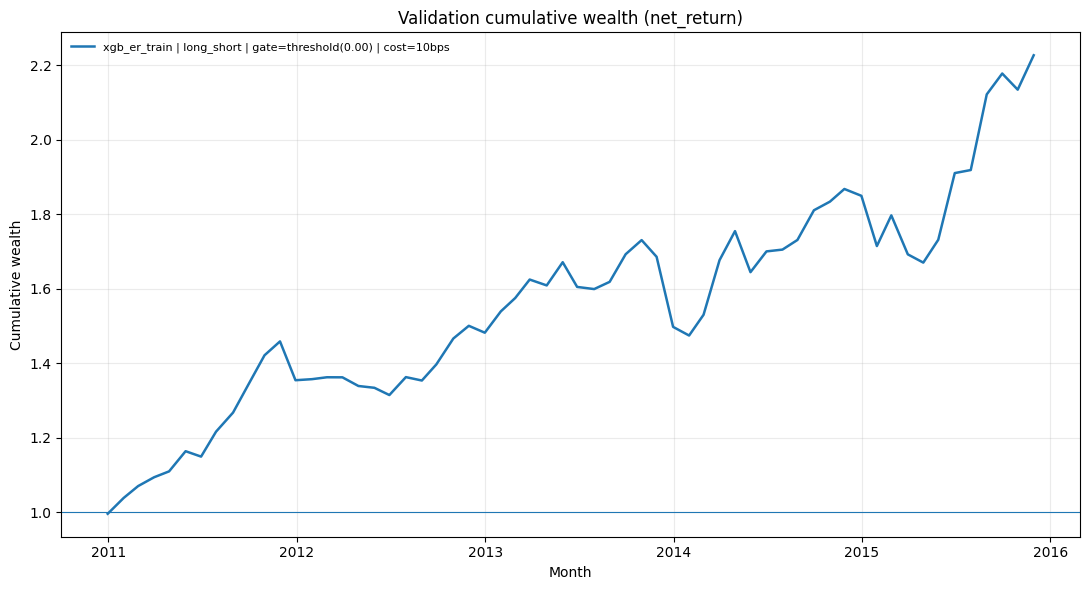

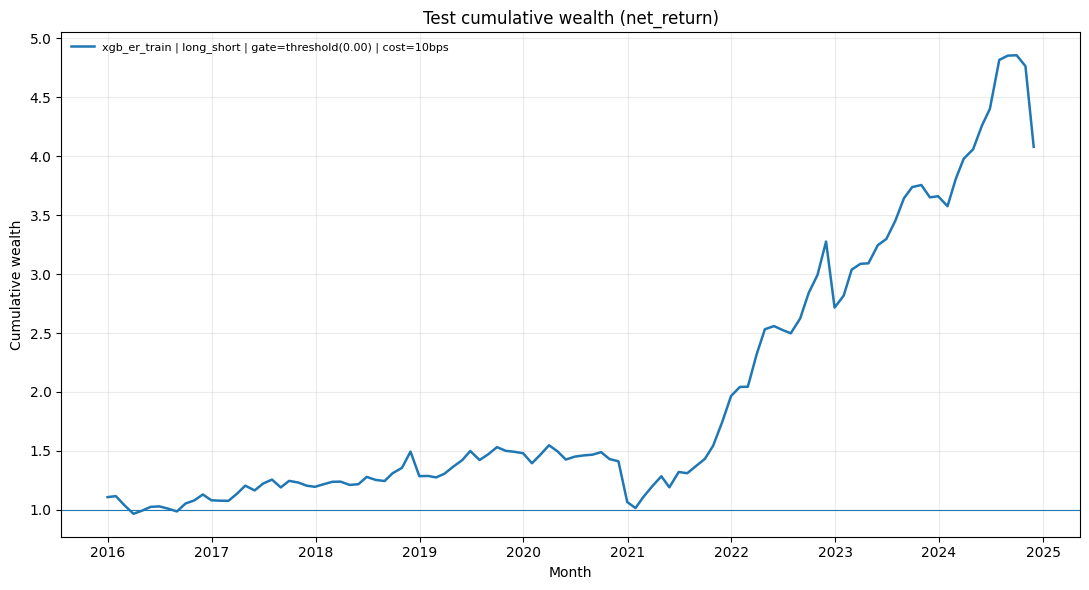

In [15]:
# Cell 15: Plot cumulative wealth for the chosen specification

def plot_cumulative_wealth(
    monthly: pd.DataFrame,
    specs: pd.DataFrame,
    split: str,
    return_col: str = "net_return",
    path: Path | None = None,
) -> None:
    fig, ax = plt.subplots(figsize=(11, 6))

    for _, spec in specs.iterrows():
        mask = (
            monthly["split"].eq(split)
            & monthly["score_label"].eq(spec["score_label"])
            & monthly["rule"].eq(spec["rule"])
            & monthly["q"].eq(spec["q"])
            & monthly["sign_gate"].eq(spec["sign_gate"])
            & monthly["threshold_gate"].eq(spec["threshold_gate"])
            & monthly["zero_threshold"].eq(spec["zero_threshold"])
            & monthly["one_way_cost_bps"].eq(spec["one_way_cost_bps"])
        )

        part = monthly.loc[mask].sort_values("month")
        if part.empty:
            continue

        wealth = (1.0 + part[return_col].fillna(0.0)).cumprod()

        gate_label = "threshold" if spec["threshold_gate"] else ("sign" if spec["sign_gate"] else "none")
        if spec["threshold_gate"]:
            gate_label = f"threshold({spec['zero_threshold']:.2f})"

        label = (
            f"{spec['score_label']} | {spec['rule']} | "
            f"gate={gate_label} | cost={spec['one_way_cost_bps']:.0f}bps"
        )

        ax.plot(part["month"], wealth, linewidth=1.8, label=label)

    ax.axhline(1.0, linewidth=0.8)
    ax.set_title(f"{split.title()} cumulative wealth ({return_col})")
    ax.set_xlabel("Month")
    ax.set_ylabel("Cumulative wealth")
    ax.legend(fontsize=8, frameon=False)
    ax.grid(alpha=0.25)
    fig.tight_layout()

    if path is not None:
        fig.savefig(path, dpi=160)

    plt.show()


plot_specs = pd.DataFrame([chosen_spec])

plot_cumulative_wealth(
    portfolio_monthly,
    plot_specs,
    split="validation",
    return_col="net_return",
    path=FIGURE_DIR / "validation_chosen_score_strategy_cumulative_wealth.png",
)

plot_cumulative_wealth(
    portfolio_monthly,
    plot_specs,
    split="test",
    return_col="net_return",
    path=FIGURE_DIR / "test_chosen_score_strategy_cumulative_wealth.png",
)


In [16]:
# Cell 16: Save compact report tables

validation_rank_ic.to_csv(OUTPUT_DIR / "validation_score_rank_ic_ranking.csv", index=False)
validation_portfolios.to_csv(OUTPUT_DIR / "validation_score_strategy_ranking.csv", index=False)
selection_table.to_csv(OUTPUT_DIR / "validation_selection_table_10bps.csv", index=False)

for cost_bps, ranking in validation_rankings_by_cost.items():
    ranking.to_csv(OUTPUT_DIR / f"validation_score_strategy_ranking_{int(cost_bps)}bps.csv", index=False)

pd.DataFrame([chosen_spec]).to_csv(OUTPUT_DIR / "chosen_validation_specification.csv", index=False)
chosen_test.to_csv(OUTPUT_DIR / "test_performance_of_chosen_validation_spec.csv", index=False)

print("Saved outputs to:")
print(OUTPUT_DIR)
print(FIGURE_DIR)


Saved outputs to:
/home/aturin/ML/ML_For_Finance_Project-AxelTurinPlessia-362559-ClementMeddeb-346164/outputs/backtests
/home/aturin/ML/ML_For_Finance_Project-AxelTurinPlessia-362559-ClementMeddeb-346164/outputs/backtests/figures


In [17]:
# Cell 17: Optional sanity table: score correlations on validation

def score_correlation_table(data: pd.DataFrame, score_columns: dict, split: str = "validation") -> pd.DataFrame:
    cols = [col for col in score_columns.values() if col in data.columns]
    labels = {v: k for k, v in score_columns.items()}

    part = data.loc[data["split"].eq(split), cols].copy()
    corr = part.corr(method="spearman")
    corr = corr.rename(index=labels, columns=labels)
    return corr

validation_score_corr = score_correlation_table(work, score_columns, split="validation")
validation_score_corr.to_csv(OUTPUT_DIR / "validation_score_spearman_correlation.csv")

validation_score_corr

,naive_momentum,naive_reversal,ridge,elastic_net,xgb_regressor,logistic_classifier,xgb_classifier,logistic_er_train,xgb_er_train,xgb_hybrid_alpha_0.25,xgb_hybrid_alpha_0.50,xgb_hybrid_alpha_0.75,xgb_hybrid_alpha_0.90,xgb_er_pred_return_buckets,xgb_er_pred_classifier_buckets
naive_momentum,1.000000,-0.038647,-0.054663,0.046301,0.066733,0.201049,0.431987,0.152229,0.402698,0.220310,0.233291,0.268198,0.341317,0.023809,0.012291
naive_reversal,-0.038647,1.000000,0.006221,0.035852,-0.005013,-0.143330,-0.088605,-0.128286,-0.062451,-0.028782,-0.031229,-0.037999,-0.054048,0.004285,0.007131
ridge,-0.054663,0.006221,1.000000,0.293441,0.598242,-0.029492,-0.141389,-0.005723,-0.087233,-0.028082,-0.032640,-0.045080,-0.073614,0.614773,0.616568
elastic_net,0.046301,0.035852,0.293441,1.000000,0.508857,-0.090480,-0.106585,-0.086176,-0.100350,-0.058148,-0.060423,-0.066599,-0.081322,0.529605,0.528573
xgb_regressor,0.066733,-0.005013,0.598242,0.508857,1.000000,-0.071858,-0.092765,-0.058568,-0.044373,0.125892,0.121529,0.107921,0.066617,0.951031,0.950596
logistic_classifier,0.201049,-0.143330,-0.029492,-0.090480,-0.071858,1.000000,0.403400,0.846347,0.367182,0.062091,0.075547,0.112807,0.199464,-0.067399,-0.078806
xgb_classifier,0.431987,-0.088605,-0.141389,-0.106585,-0.092765,0.403400,1.000000,0.272548,0.880998,0.431081,0.460112,0.537982,0.704413,-0.153997,-0.172966
logistic_er_train,0.152229,-0.128286,-0.005723,-0.086176,-0.058568,0.846347,0.272548,1.000000,0.402994,0.040576,0.049686,0.075214,0.135776,-0.059200,-0.066553
xgb_er_train,0.402698,-0.062451,-0.087233,-0.100350,-0.044373,0.367182,0.880998,0.402994,1.000000,0.445403,0.471057,0.539287,0.681395,-0.118513,-0.134318
xgb_hybrid_alpha_0.25,0.220310,-0.028782,-0.028082,-0.058148,0.125892,0.062091,0.431081,0.040576,0.445403,1.000000,0.999156,0.988281,0.918949,-0.116118,-0.117508


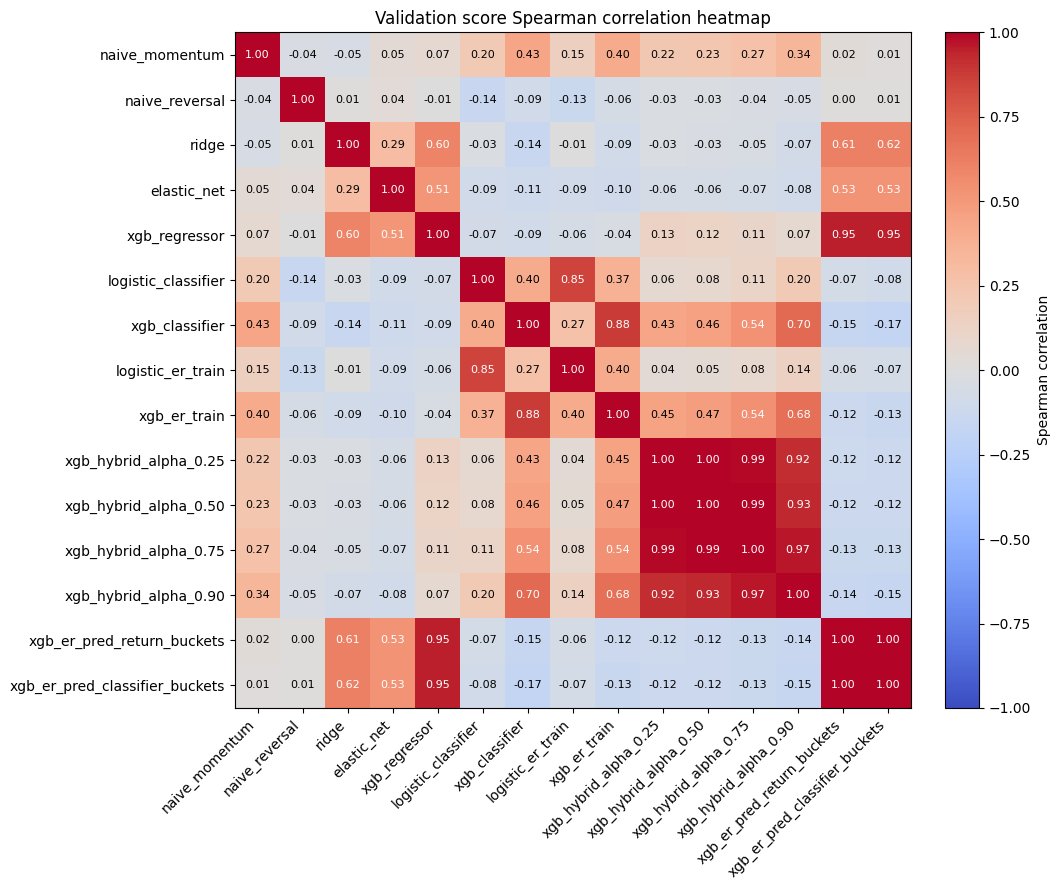

In [18]:
# Cell 18: Validation score-correlation heatmap

fig, ax = plt.subplots(figsize=(11, 9))
heatmap_values = validation_score_corr.to_numpy(dtype=float)
image = ax.imshow(heatmap_values, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(validation_score_corr.columns)))
ax.set_yticks(range(len(validation_score_corr.index)))
ax.set_xticklabels(validation_score_corr.columns, rotation=45, ha="right")
ax.set_yticklabels(validation_score_corr.index)
ax.set_title("Validation score Spearman correlation heatmap")

for i in range(validation_score_corr.shape[0]):
    for j in range(validation_score_corr.shape[1]):
        value = heatmap_values[i, j]
        color = "white" if abs(value) > 0.5 else "black"
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", color=color, fontsize=8)

fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04, label="Spearman correlation")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "validation_score_spearman_correlation_heatmap.png", dpi=180, bbox_inches="tight")
plt.show()


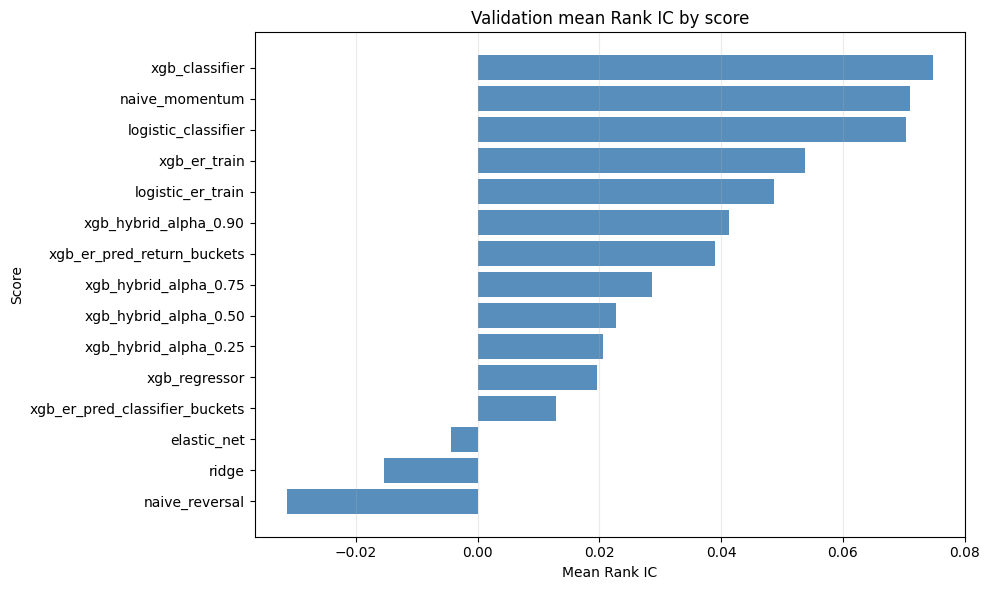

In [19]:
# Cell 19: Rank IC bar chart

rank_ic_plot = validation_rank_ic.sort_values("mean_rank_ic", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(rank_ic_plot["score_label"], rank_ic_plot["mean_rank_ic"], color="steelblue", alpha=0.9)
ax.set_title("Validation mean Rank IC by score")
ax.set_xlabel("Mean Rank IC")
ax.set_ylabel("Score")
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "validation_score_rank_ic_bar_chart.png", dpi=160, bbox_inches="tight")
plt.show()
